# Unsupervised Learning Algorithms




In [1]:
from sklearn.datasets import load_iris, load_breast_cancer,  load_digits
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# packages to create artificial data for clustering purposes
from sklearn.datasets import make_moons, make_blobs

### PCA

In [ ]:
# get the data from toy dataset
cancer = load_breast_cancer()
# print( cancer.DESCR)
df= pd.DataFrame(data= np.c_[cancer['data'], cancer['target']],columns= list(cancer['feature_names']) + ['target'])
df['target_names'] = cancer.target_names[df['target'].astype(int)]
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_names
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0.0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0.0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0.0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0.0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0.0,malignant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0.0,malignant
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0.0,malignant
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0.0,malignant
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0.0,malignant


<Axes: xlabel='mean radius', ylabel='Count'>

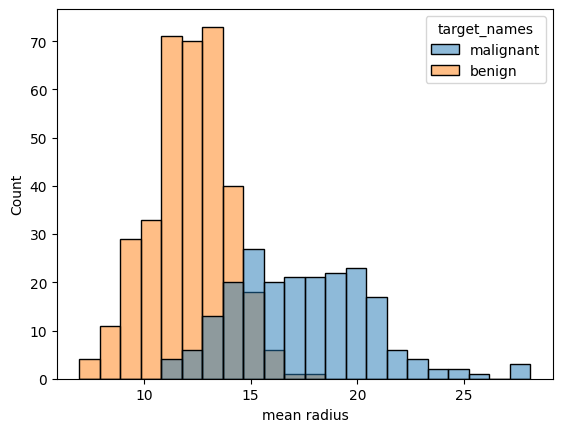

In [ ]:
# when using raw features, we can visualize in 2D only two features at once, hard to see the pattern
sns.histplot(x='mean radius', hue = 'target_names', data=df)

<Axes: xlabel='mean radius', ylabel='mean concave points'>

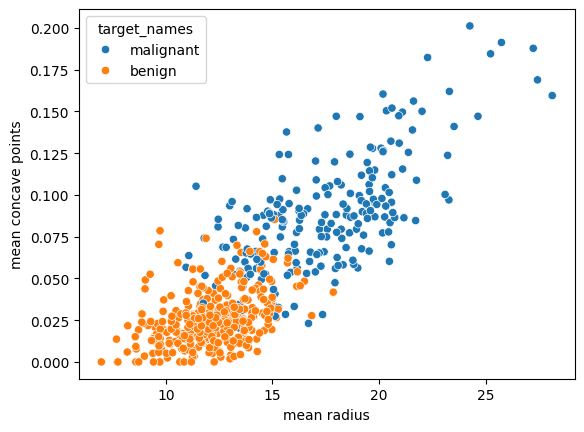

In [ ]:
sns.scatterplot(x='mean radius', y='mean concave points', hue = 'target_names', data=df)

#### PCA is essentially a method that reduces the dimension of the feature space in such a way that new variables are orthogonal to each other (i.e. they are independent or not correlated).
- cancer data-set has 30 features - let’s reduce it to only 3 principal features and then we can visualize the scatter plot of these new independent variables

In [ ]:
# Separating out the features
x = df.loc[:, cancer['feature_names']].values
y = df.loc[:,['target']].values
print(x.shape)
print(y.shape)

(569, 30)
(569, 1)


In [ ]:
# Standardizing the features
X = StandardScaler().fit_transform(x)

In [ ]:
# PCA projection to lower dimensional space (number of dimensions depends on n-components parameter)
pcamodel = PCA(n_components=3)
principalComponents = pcamodel.fit_transform(X)
principalDf = pd.DataFrame(data = principalComponents, columns = ['pc1', 'pc2', 'pc3'])
finalDf = pd.concat([principalDf, df[['target']], df[['target_names']]], axis = 1)
finalDf


,pc1,pc2,pc3,target,target_names
0,9.192837,1.948583,-1.123166,0.0,malignant
1,2.387802,-3.768172,-0.529293,0.0,malignant
2,5.733896,-1.075174,-0.551748,0.0,malignant
3,7.122953,10.275589,-3.232790,0.0,malignant
4,3.935302,-1.948072,1.389767,0.0,malignant
...,...,...,...,...,...
564,6.439315,-3.576817,2.459487,0.0,malignant
565,3.793382,-3.584048,2.088476,0.0,malignant
566,1.256179,-1.902297,0.562731,0.0,malignant
567,10.374794,1.672010,-1.877029,0.0,malignant


In [ ]:
# another way of defining how much variance must be kept- unknown number of dimensions or principal components
pcamodel2 = PCA(.9)
principalComponents2 = pcamodel2.fit_transform(X)
print(principalComponents2.shape)

(569, 7)


<Axes: xlabel='mean radius', ylabel='mean concave points'>

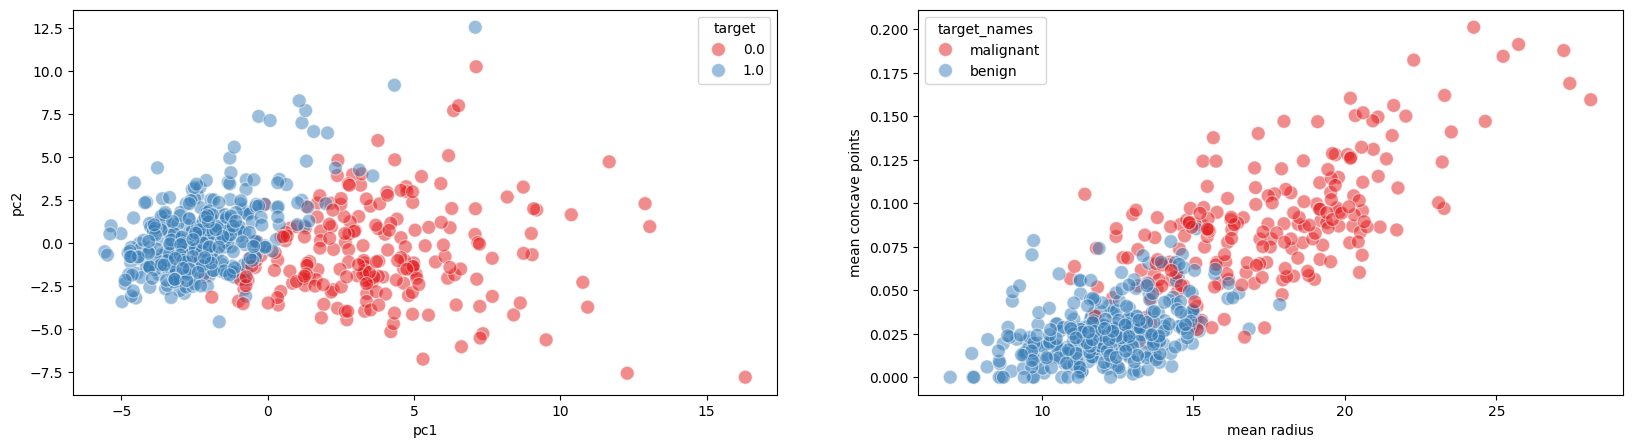

In [ ]:
# to define the pallete for graphs
# many different palletes can be chosen https://seaborn.pydata.org/tutorial/color_palettes.html
# sns.set_palette('Paired')
sns.set_palette('Set1') # change the parameter (pallete name) to get different graph appearance

fig, axs = plt.subplots(1,2, figsize=(20, 5))
sns.scatterplot(x= 'pc1', y='pc2', hue='target', data=finalDf, ax=axs[0], alpha=0.5, s=100)
# compare visual results to the previous plot between original feature and target variable
sns.scatterplot(x='mean radius', y='mean concave points', hue = 'target_name', data=df, ax=axs[1], alpha=0.5, s=100)
# you can see that applying linear classifier would be a good approach after using PCA

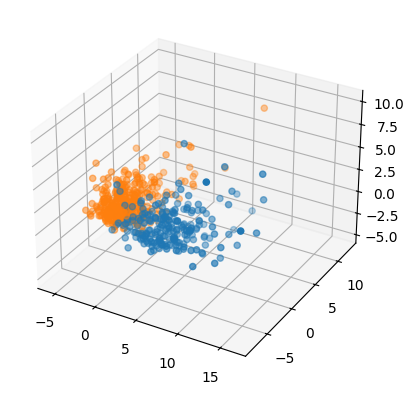

In [ ]:
# plot all 3 axis
# first a bit of aesthetics and colormap change
from matplotlib.colors import ListedColormap
cmap = ListedColormap(sns.color_palette("tab10", 2).as_hex()) # create color map
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(finalDf['pc1'],finalDf['pc2'],finalDf['pc3'], c = finalDf['target'], cmap=cmap)


### Feature importance

In [ ]:
# how much variance is actually explained by 3 principal components?
print((pcamodel.explained_variance_ratio_), sum(pcamodel.explained_variance_ratio_))
print(pcamodel.components_.shape) # has shape [n_components, n_features]

[0.44272026 0.18971182 0.09393163] 0.7263637090899083
(3, 30)


In [ ]:
print((pcamodel2.explained_variance_ratio_)) # 7 PC retain 90% of the variance of original dataset


[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734]


In [ ]:
print(pcamodel.components_)
print(pcamodel.components_.shape)


[[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]
 [-0.00853124  0.0645499  -0.00931422  0.02869953 -0.1042919  -0.07409157
   0.00273384 -0.02556354 -0.04023994 -0.02257409  0.26848139  0.37463367
   0.26664537  0.21600653  0.30883898  0.15477972  0.17646374  0.22465757
   0.28858429  0.21150376 -0.04750699

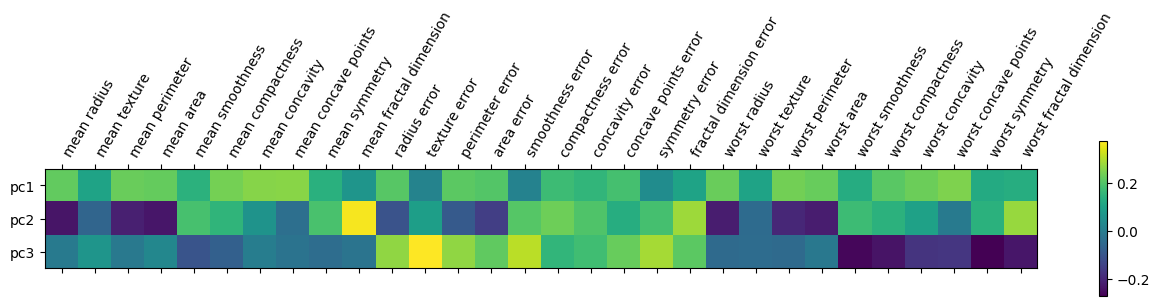

In [ ]:
# How get the graphical overview on how PC are represented by raw features. Hard to see it from previous print results
plt.matshow(pcamodel.components_, cmap='viridis')
plt.yticks([0, 1, 2], ['pc1', 'pc2', 'pc3'])
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)),
cancer.feature_names, rotation=60, ha='left');
# plt.suptitle("pca_components_cancer")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 13.9 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.8.0
    Uninstalling matplotlib-3.8.0:
      Successfully uninstalled matplotlib-3.8.0
[pca] >Column labels are auto-completed.
[pca] >Row labels are auto-completed.
[pca] >The PCA reduction is performed on the [30] columns of the input dataframe.
[pca] >Fit using PCA.
[pca] >Compute loadings and PCs.
[pca] >Compute explained variance.
[pca] >Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[3]
[pca] >Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[pca] >Outlier detection using SPE/DmodX with n_std=[3]


[scatterd] >INFO> Create scatterplot
[scatterd] >INFO> Create scatterplot


[pca] >Plot PC1 vs PC2 with loadings.
[scatterd]> WARNING use the standardized verbose status. The status [1-6] will be deprecated in future versions.
[pca] >Plot PC1 vs PC2 vs PC3 with loadings.
[scatterd]> WARNING use the standardized verbose status. The status [1-6] will be deprecated in future versions.


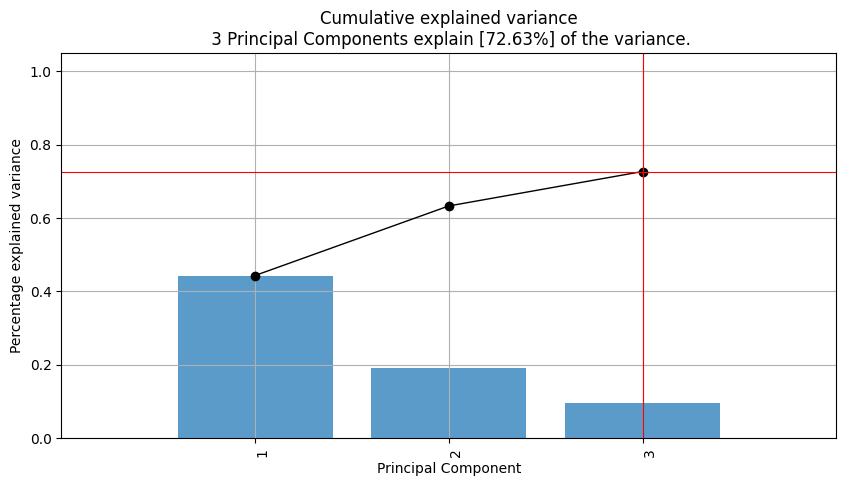

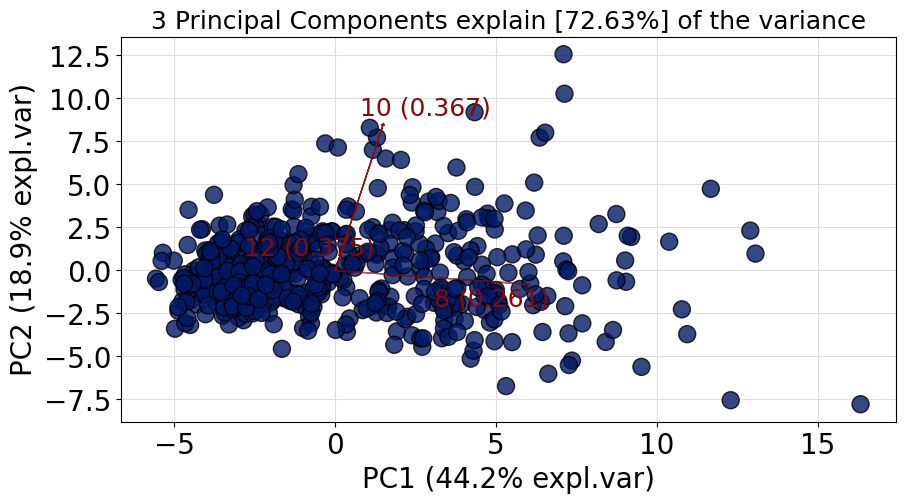

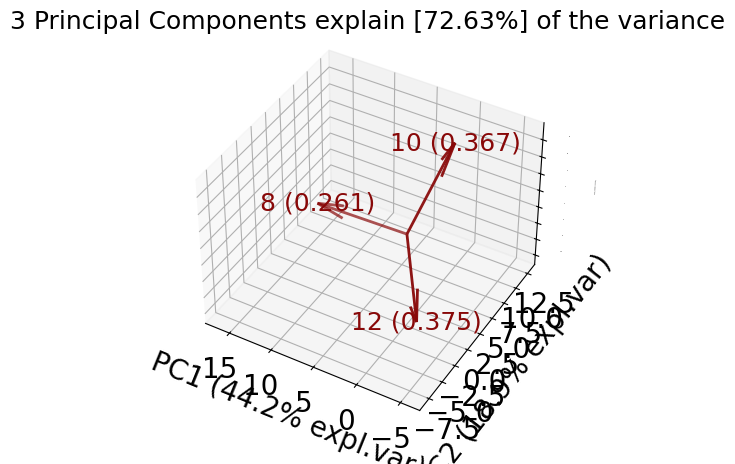

In [ ]:
# another package to better understand results of pca when comapred sklearn.decomposition.PCA
!pip install pca # pca package is not part of colab, it must be installed
from pca import pca

model = pca(n_components=3)
results = model.fit_transform(X)

# Plot explained variance
fig, ax = model.plot(figsize=(10,5))
# Make biplot with the number of features
fig, ax = model.biplot(n_feat=3, legend=True, figsize=(10,5))
fig, ax = model.biplot3d(n_feat=3, cmap=None, legend=True, figsize=(8,5))

K-means

*The* K-means algorithm aims to choose centroids that minimise the inertia, or within-cluster sum-of-squares criterion:



Inertia can be recognized as a measure of how internally coherent clusters are. It suffers from various drawbacks:

Inertia makes the assumption that clusters are convex and isotropic, which is not always the case. It responds poorly to elongated clusters, or manifolds with irregular shapes.

Inertia is not a normalized metric: we just know that lower values are better and zero is optimal. But in very high-dimensional spaces, Euclidean distances tend to become inflated (this is an instance of the so-called “curse of dimensionality”). Running a dimensionality reduction algorithm such as Principal component analysis (PCA) prior to k-means clustering can alleviate this problem and speed up the computations.

### Digit data example

In [ ]:
# the digits consist of 1,797 samples with 64 features, where each of the 64 features is the brightness of one pixel in an 8×8 image:
data, targets = load_digits(return_X_y=True)
(n_samples, n_features), n_digits = data.shape, np.unique(targets).size
# print basic info about data
print(f"# digits: {n_digits}; # samples: {n_samples}; # features {n_features}" )

# digits: 10; # samples: 1797; # features 64


In [ ]:
kmeans = KMeans(init="k-means++", n_clusters=10, random_state=10, n_init=20)
# kmeans.fit(data)
# cluster = kmeans.predict(data)
clusters = kmeans.fit_predict(data) # Compute cluster centers and predict cluster index for each sample

print(kmeans.cluster_centers_.shape)
print(*kmeans.labels_)
print(*targets)
# !!! labels or data annotation do not correspond to target variable


(10, 64)
3 1 1 0 6 5 8 4 5 5 3 9 2 0 6 7 8 4 1 5 3 9 2 0 9 7 8 9 1 5 3 5 7 7 8 7 3 5 1 5 1 6 9 4 4 0 7 9 3 3 1 1 4 1 4 3 9 1 8 0 0 4 0 0 6 8 8 8 6 1 9 7 3 5 7 9 1 9 3 3 9 4 8 0 2 9 4 6 8 0 9 0 0 1 4 1 1 6 0 1 6 3 7 4 8 5 8 9 4 7 6 6 4 2 1 1 1 7 4 5 7 6 1 1 6 5 3 1 5 1 3 9 2 0 6 7 8 4 1 5 3 9 2 0 6 7 8 4 1 5 3 9 2 0 6 7 8 4 1 5 3 0 7 7 8 7 3 5 1 5 1 6 9 4 4 0 7 9 3 3 2 2 4 1 2 3 9 2 8 0 0 4 0 0 6 8 8 8 1 5 9 7 3 5 7 2 1 2 3 3 9 4 8 0 2 9 4 0 9 0 5 9 4 8 1 6 0 9 6 3 7 4 8 5 8 9 4 7 1 6 4 2 1 2 2 7 7 9 1 1 6 5 3 1 5 1 3 1 2 0 6 5 8 4 5 7 3 1 2 0 6 7 8 4 1 4 3 1 2 0 6 7 8 4 1 5 3 5 7 5 8 5 3 5 1 5 1 6 1 4 4 0 7 1 3 3 2 2 4 5 2 3 9 2 8 0 0 4 0 0 6 8 8 8 6 4 1 7 3 4 7 2 5 2 3 3 1 4 8 0 2 1 4 6 8 0 1 0 4 1 4 8 1 6 0 1 6 3 5 0 8 4 8 1 4 7 6 6 4 2 5 2 2 5 4 9 7 6 5 5 6 9 3 1 4 0 3 9 2 0 6 7 8 4 5 5 3 9 2 0 6 7 8 4 1 5 3 9 2 0 6 7 8 4 5 5 3 5 5 7 8 5 3 5 5 5 5 6 9 4 4 0 7 9 3 3 2 2 4 5 2 3 2 2 8 0 5 4 5 5 6 8 8 8 6 5 9 5 3 5 7 2 1 2 3 3 9 4 8 0 2 9 4 9 8 0 9 0 5 9 7 8 5 6 0 9 6 3 7 0 8 5 1 9 4 7

In [ ]:
print(kmeans.cluster_centers_.shape)

(10, 64)


In [ ]:
print(kmeans.cluster_centers_)


[[ 0.00000000e+00  5.96590909e-01  8.71590909e+00  1.46306818e+01
   1.40454545e+01  7.00568182e+00  5.45454545e-01 -2.77555756e-16
   1.13636364e-02  4.20454545e+00  1.26022727e+01  9.07386364e+00
   1.12386364e+01  1.19602273e+01  1.84659091e+00  1.13636364e-02
   5.68181818e-03  1.85795455e+00  3.53977273e+00  3.47159091e+00
   1.17897727e+01  9.92613636e+00  8.57954545e-01  6.93889390e-17
  -2.81892565e-18  3.97727273e-02  9.09090909e-01  8.30681818e+00
   1.38295455e+01  6.76704545e+00  3.06818182e-01 -5.63785130e-18
   0.00000000e+00  6.25000000e-02  6.81818182e-01  4.60227273e+00
   1.17613636e+01  1.23125000e+01  2.32954545e+00  0.00000000e+00
  -2.25514052e-17  4.54545455e-01  1.44318182e+00  6.93181818e-01
   4.17613636e+00  1.23693182e+01  6.36363636e+00  5.68181818e-03
  -2.42861287e-17  9.26136364e-01  7.28409091e+00  6.59090909e+00
   8.59659091e+00  1.37215909e+01  6.09090909e+00  1.76136364e-01
  -1.40946282e-18  4.77272727e-01  9.52840909e+00  1.49829545e+01
   1.41420

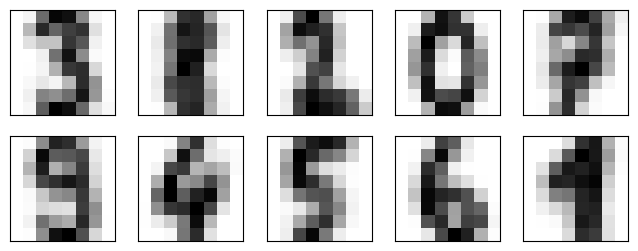

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8) # reshape cluster centers to image 8x8

# show results as image
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

# We see that even without the labels, KMeans is able to find clusters whose centers are recognizable digits, with perhaps the exception of 1 and 8.

### Check the accuracy


Because k-means knows nothing about the identity of the cluster, the 0–9 labels may be permuted regarding the target variable
If you look at the image above, you can see that labels are permuted

 - note-
this can be done only if we have target variable- so here only for educational purposis, in reality, we do have that option
We can fix this by matching each learned cluster label with the true labels found in them

In [ ]:
np.set_printoptions(edgeitems=10)
labels = np.zeros_like(clusters)
print(labels, labels.shape)
print(clusters, clusters.shape)
print(targets, targets.shape)

[0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0] (1797,)
[3 1 1 0 6 5 8 4 5 5 ... 5 6 1 1 6 5 3 1 5 5] (1797,)
[0 1 2 3 4 5 6 7 8 9 ... 5 4 8 8 4 9 0 8 9 8] (1797,)


In [ ]:
# We will use a Scipy package and its method "mode"
# Mode returns an array of the modal (i.e. most common) value in the input array.
from scipy.stats import mode

for i in range(10):
    mask = (clusters == i) # for each digit we mask the data and focus only on one digit per one loop
    # print(*targets[mask])
    # print(*mask)
    print(*targets[mask].shape)
    print(*mask.shape)

    labels[mask] = mode(targets[mask])[0] # I am assigning the most common value to the variable labels at the index positions defined by mask
    print('cluster number', i, ', most common valus in the cluster', *[mode(targets[mask])[0]])

176
1797
cluster number 0 , most common valus in the cluster 3
223
1797
cluster number 1 , most common valus in the cluster 8
175
1797
cluster number 2 , most common valus in the cluster 2
179
1797
cluster number 3 , most common valus in the cluster 0
204
1797
cluster number 4 , most common valus in the cluster 7
249
1797
cluster number 5 , most common valus in the cluster 9
166
1797
cluster number 6 , most common valus in the cluster 4
150
1797
cluster number 7 , most common valus in the cluster 5
182
1797
cluster number 8 , most common valus in the cluster 6
93
1797
cluster number 9 , most common valus in the cluster 1


In [ ]:
mode(targets[mask])

ModeResult(mode=1, count=55)

In [ ]:
targets[mask]

array([1, 1, 4, 7, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 4, 1, 9, 9, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1,
       4, 8, 9, 9, 4, 9, 9, 9, 9, 7, 9, 9, 9, 9, 9, 9, 9, 8, 8, 8, 8, 4,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 1, 1, 1, 1, 1, 1, 1, 1, 6, 9,
       9, 9, 9, 9, 4])

In [ ]:
print(*labels)
print(*targets)

0 8 8 3 4 9 6 7 9 9 0 1 2 3 4 5 6 7 8 9 0 1 2 3 1 5 6 1 8 9 0 9 5 5 6 5 0 9 8 9 8 4 1 7 7 3 5 1 0 0 8 8 7 8 7 0 1 8 6 3 3 7 3 3 4 6 6 6 4 8 1 5 0 9 5 1 8 1 0 0 1 7 6 3 2 1 7 4 6 3 1 3 3 8 7 8 8 4 3 8 4 0 5 7 6 9 6 1 7 5 4 4 7 2 8 8 8 5 7 9 5 4 8 8 4 9 0 8 9 8 0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 3 5 5 6 5 0 9 8 9 8 4 1 7 7 3 5 1 0 0 2 2 7 8 2 0 1 2 6 3 3 7 3 3 4 6 6 6 8 9 1 5 0 9 5 2 8 2 0 0 1 7 6 3 2 1 7 3 1 3 9 1 7 6 8 4 3 1 4 0 5 7 6 9 6 1 7 5 8 4 7 2 8 2 2 5 5 1 8 8 4 9 0 8 9 8 0 8 2 3 4 9 6 7 9 5 0 8 2 3 4 5 6 7 8 7 0 8 2 3 4 5 6 7 8 9 0 9 5 9 6 9 0 9 8 9 8 4 8 7 7 3 5 8 0 0 2 2 7 9 2 0 1 2 6 3 3 7 3 3 4 6 6 6 4 7 8 5 0 7 5 2 9 2 0 0 8 7 6 3 2 8 7 4 6 3 8 3 7 8 7 6 8 4 3 8 4 0 9 3 6 7 6 8 7 5 4 4 7 2 9 2 2 9 7 1 5 4 9 9 4 1 0 8 7 3 0 1 2 3 4 5 6 7 9 9 0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 9 9 0 9 9 5 6 9 0 9 9 9 9 4 1 7 7 3 5 1 0 0 2 2 7 9 2 0 2 2 6 3 9 7 9 9 4 6 6 6 4 9 1 9 0 9 5 2 8 2 0 0 1 7 6 3 2 1 7 1 6 3 1 3 9 1 5 6 9 4 3 1 4 0 5 3 6 9 8 1 7 5 1 4 7 2 

In [ ]:
# now we can compute the accuracy between labels(i.e. cluster) and target
# this is only for educational purposes and understanding clustering mechanisms, in practive you will not have an information about target variable
from sklearn.metrics import accuracy_score
accuracy_score(targets, labels)

0.7918753478018921

In [ ]:
from sklearn.metrics import cohen_kappa_score # expresses the level of agreement between two annotators on a classification problem
cohen_kappa_score(targets, labels)


0.7687920649839067

#### Check which clusters are problematic


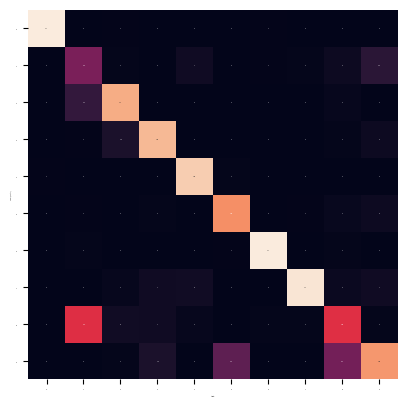

In [ ]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(labels, targets)
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('target')
plt.ylabel('label (cluster)');


#### Preprocessing with t-SNE before kmeans
 - t-SNE is a nonlinear embedding algorithm good at preserving points within clusters

In [ ]:
from sklearn.manifold import TSNE

# Project the data: this step will take several seconds
tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(data)

# digits_proj = PCA(n_components=2).fit_transform(data) # you can try to use PCA insted aof tsne
print(digits_proj.shape)


(1797, 2)


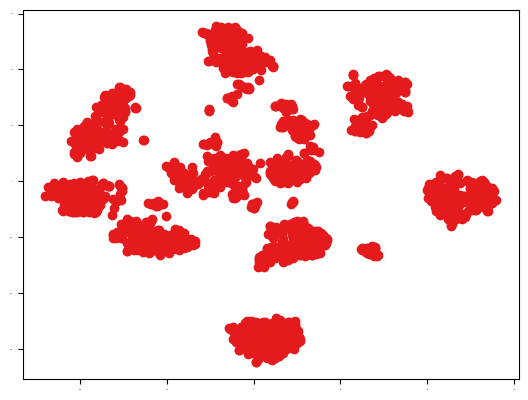

In [ ]:
# fig = plt.figure(figsize =(12,4))
plt.scatter(digits_proj[:,0], digits_proj[:,1])

In [ ]:
# Compute the clusters
kmeans = KMeans(init="k-means++", n_clusters=10, random_state=10, n_init=20)
clusters = kmeans.fit_predict(digits_proj)

# Permute the labels as before to assign the labels to clusters
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(targets[mask])[0]

# Compute the accuracy
accuracy_score(targets, labels)


0.9415692821368948

In [ ]:
cohen_kappa_score(targets, labels)

0.9350801275379512

([], [])

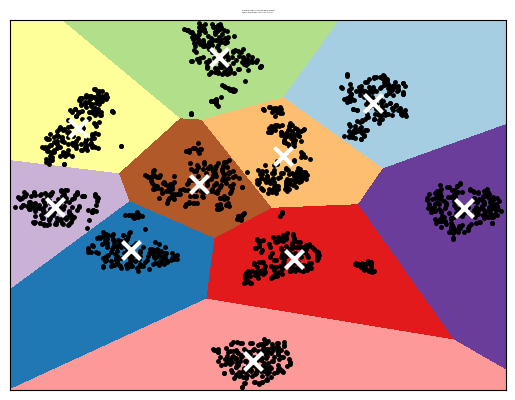

In [ ]:
# show clustering resutls
reduced_data = digits_proj
# reduced_data = PCA(n_components=2).fit_transform(data)
kmeans = KMeans(init="k-means++", n_clusters=n_digits, n_init=20)
kmeans.fit(reduced_data.astype('double'))

# Step size of the mesh. Decrease to increase the quality of the VQ.
h = .02     # point in the mesh [x_min, x_max]x[y_min, y_max].

# Plot the decision boundary. For that, we will assign a color to each point of meshgrid
x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Obtain labels for each point in mesh. Use last trained model.
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure()
plt.clf()
plt.imshow(Z, interpolation="nearest",
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap=plt.cm.Paired, aspect="auto", origin="lower")

plt.plot(reduced_data[:, 0], reduced_data[:, 1], 'k.', markersize=5)
# Plot the centroids as a white X
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker="x", s=169, linewidths=3,
            color="w", zorder=10)
plt.title("K-means clustering on the digits dataset\n"
          "Centroids are marked with white cross")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())

### Spectral Clustering
 - K-means clustering is limited to linear cluster boundaries
 - the boundaries between k-means clusters will always be linear, which means that it will fail for more complicated boundaries

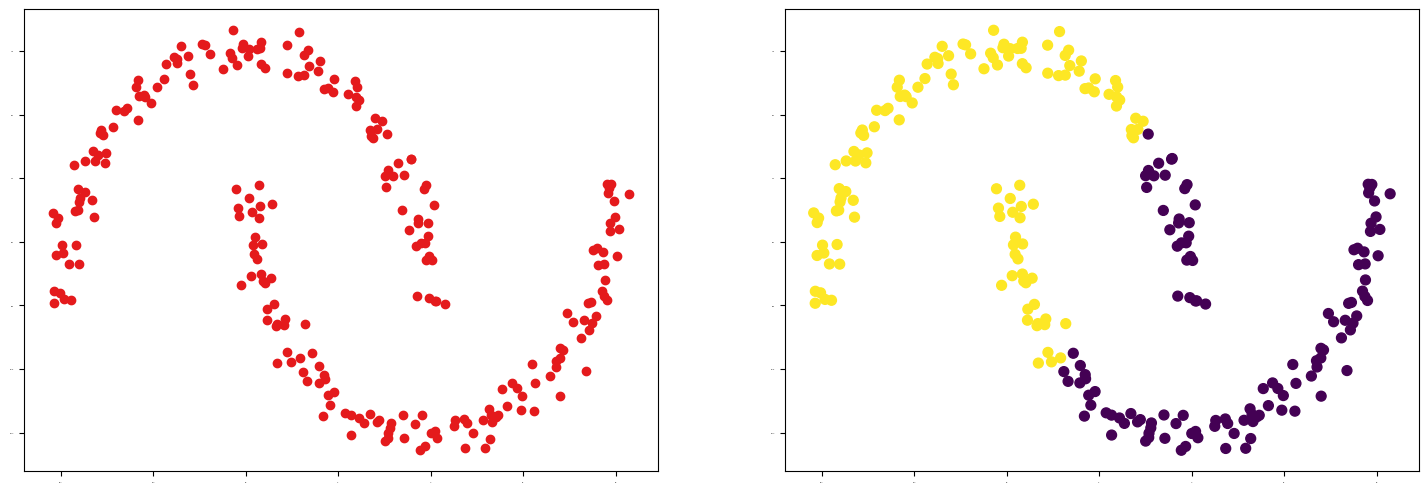

In [ ]:
X, y = make_moons(250, noise=.05, random_state=10) # get a toy data

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
ax1.scatter(X[:, 0], X[:, 1]);

labels = KMeans(init="k-means++", n_clusters=2, n_init=20).fit_predict(X) # perform kmeans clustering
ax2.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

#### Kernelized k-means
 - SpectralClustering estimator
 - Uses the graph of nearest neighbors to compute a higher-dimensional representation of the data, and then assigns labels using a k-means algorithm

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


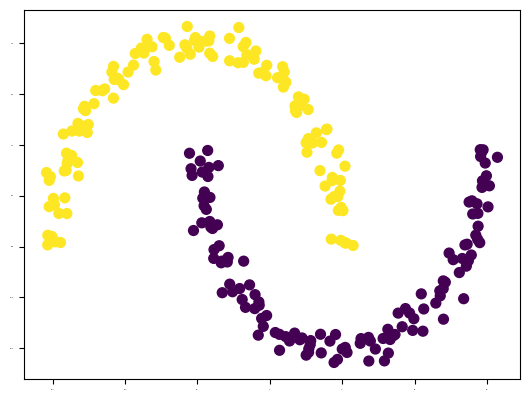

In [ ]:
from sklearn.cluster import SpectralClustering, DBSCAN

model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', assign_labels='kmeans')
# explain parameters
clusters = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=clusters,
            s=50, cmap='viridis');

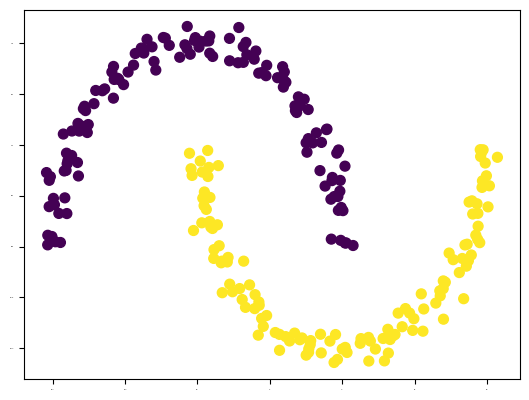

In [ ]:
# no need to specify number of clusters, however need to specify hypermarameters
dbscan = DBSCAN(eps=0.3, min_samples=5) # you can play with parameters to get different results
labels = dbscan.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

### How to decide the number of clusters?

Elbow Method
  - calculating the Within-Cluster-Sum of Squared Errors (WSS) for different number of clusters (k) and selecting the k for which change in WSS first starts to diminish
  - idea behind - explained variation changes rapidly for a small number of clusters and then it slows down leading to an elbow formation in the curve

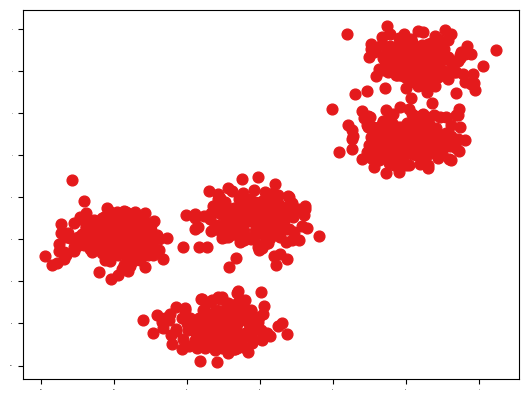

In [ ]:
X, y = make_blobs(random_state=1, centers=5,cluster_std=0.70, n_samples=1000)
plt.scatter(X[:, 0], X[:, 1], s=60)


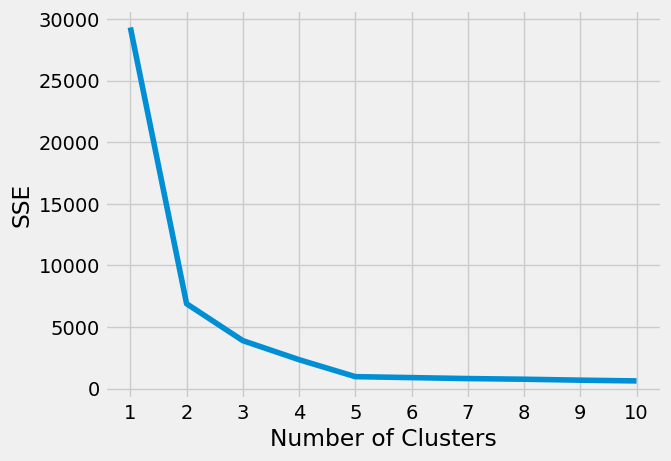

In [ ]:
kmeans_kwargs = {
    "init": "k-means++",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}

# A list holds the SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)
plt.style.use("fivethirtyeight")
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [ ]:
!pip install kneed
from kneed import KneeLocator
kl = KneeLocator(range(1, 11), sse, curve="convex", direction="decreasing")
kl.elbow

2

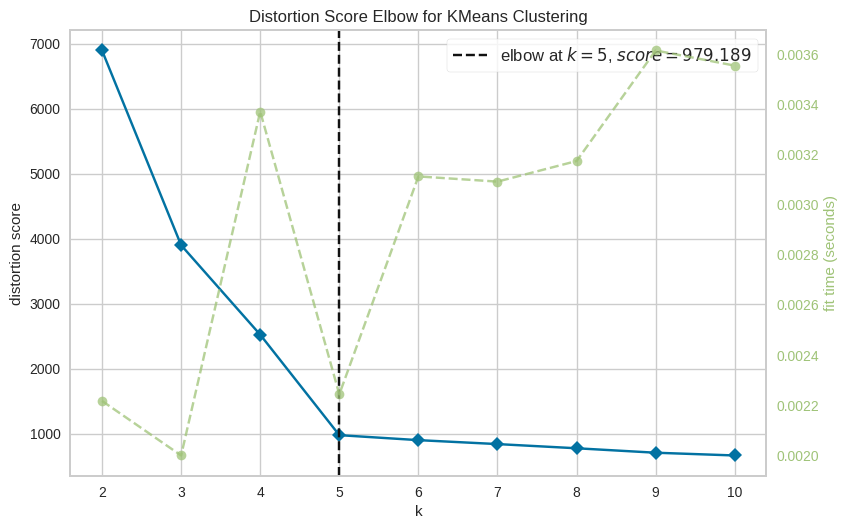

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer # here we import KElbowVisualizer
model = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(model, k=10, timings= True)
visualizer.fit(X)
visualizer.show()    # Fit data to visualizer

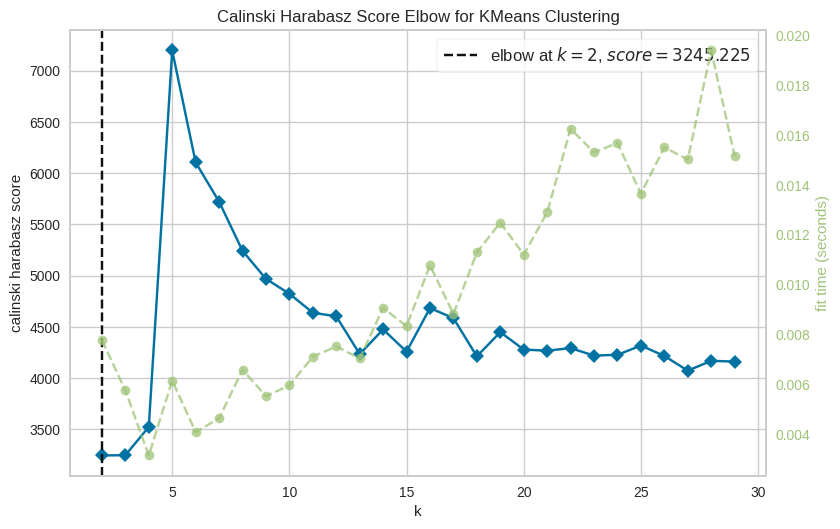

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [ ]:
# metric effect
'''
Select the scoring metric to evaluate the clusters.
The default is the mean distortion, defined by the sum of squared distances between each observation
and its closest centroid. Other metrics include:
distortion: mean sum of squared distances to centers
silhouette: mean ratio of intra-cluster and nearest-cluster distance
calinski_harabasz: ratio of within to between cluster dispersion
'''

visualizer = KElbowVisualizer(model, k=(2,30),metric='calinski_harabasz', timings= True)
visualizer.fit(X)
visualizer.show()

### Hierarchical Clustering and Dendrograms


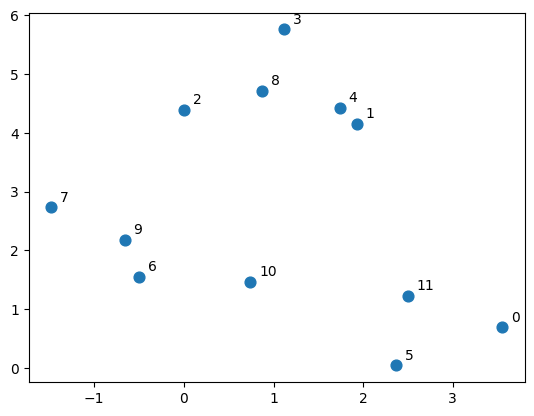

In [4]:
# import the dendrogram function and the ward clustering function from scipy
from scipy.cluster.hierarchy import dendrogram, ward

X, y = make_blobs(random_state=0, n_samples=12)
# print(y)
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], s=60)
l = [0, 1,2,3,4,5,6,7,8,9,10,11]
for i, txt in enumerate(l):
    ax.annotate(txt, (X[i,0]+0.1, X[i,1]+0.1))


Text(0.5, 1.0, 'dendrogram')

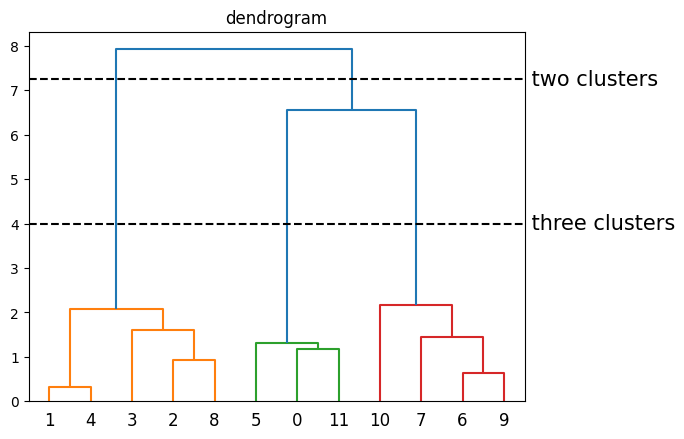

In [5]:
# apply the ward clustering to the data array X
# The scipy ward function returns an array that specifies the distances bridged when performing agg. clustering
linkage_array = ward(X)
# now we plot the dendrogram for the linkage_array containing the distances between clusters
dendrogram(linkage_array)
# mark the cuts in the tree that signify two or three clusters
ax = plt.gca()
bounds = ax.get_xbound()
ax.plot(bounds, [7.25, 7.25], '--', c='k')
ax.plot(bounds, [4, 4], '--', c='k')
ax.text(bounds[1], 7.25, ' two clusters', verticalalignment='center', fontdict={'size': 15})
ax.text(bounds[1], 4, ' three clusters', verticalalignment='center', fontdict={'size': 15})
plt.title("dendrogram")


In [12]:
# chose 2 clusters with fclusters
from scipy.cluster.hierarchy import fcluster
cluster_labels = fcluster(linkage_array, 3, criterion='maxclust')
print(cluster_labels)

[2 1 1 1 1 2 3 3 1 3 3 2]


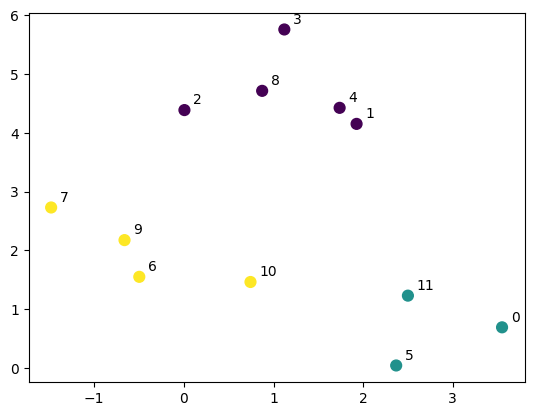

In [13]:
# visualize cluster labels with X
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], c=cluster_labels, s=60, cmap='viridis')
for i, txt in enumerate(l):
    ax.annotate(txt, (X[i,0]+0.1, X[i,1]+0.1))

### Agglomerative Clustering
- fails at separating complex shapes like the two_moons dataset

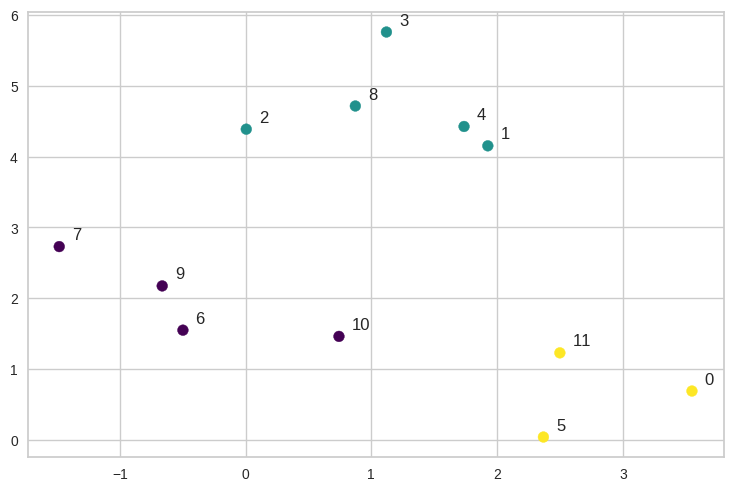

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=3)
assignment = agg.fit_predict(X)
fig, ax = plt.subplots()

ax.scatter(X[:, 0], X[:, 1], c=assignment, cmap='viridis', s=60)
for i, txt in enumerate(l):
    ax.annotate(txt, (X[i,0]+0.1, X[i,1]+0.1))

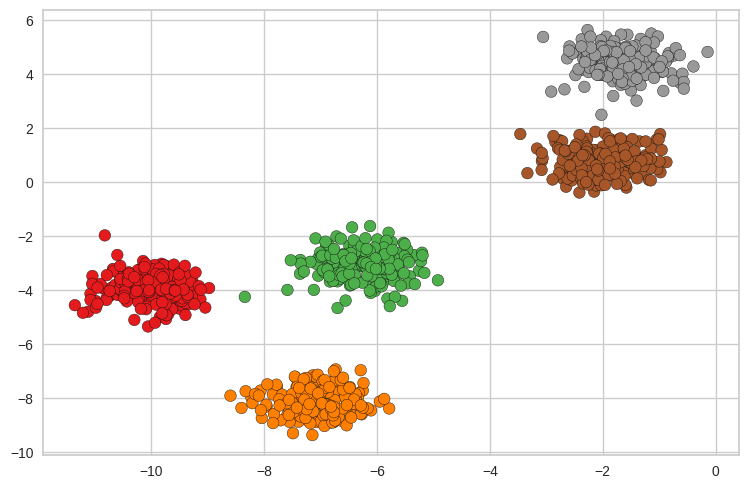

In [ ]:
from sklearn.cluster import AgglomerativeClustering
X, y = make_blobs(random_state=1, centers=5,cluster_std=0.50, n_samples=1000)
agg = AgglomerativeClustering(n_clusters=5)
assignment = agg.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=assignment, cmap='Set1', s=70, edgecolor='k')


In [ ]:
agg.children_

array([[ 284,  382],
       [ 548,  782],
       [ 616,  798],
       [ 814,  835],
       [  66,  583],
       [  39,  353],
       [  91,  623],
       [ 248,  678],
       [ 230,  330],
       [ 306,  929],
       ...,
       [1969, 1970],
       [1982, 1988],
       [1981, 1985],
       [1983, 1989],
       [1984, 1987],
       [1980, 1986],
       [1991, 1992],
       [1993, 1994],
       [1990, 1996],
       [1995, 1997]])

In [ ]:
# print(assignment)

In [ ]:
# this is how to mount google drive to be usable and reachable as data storage
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# convert colab nb to html
%%shell
jupyter-nbconvert --to html /content/drive/MyDrive/Teaching/MLP/2023_autumn/W3-Unsupervised_Learning.ipynb


[NbConvertApp] Converting notebook /content/drive/MyDrive/Teaching/MLP/2023_autumn/W3-Unsupervised_Learning.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 23 image(s).
[NbConvertApp] Writing 2184975 bytes to /content/drive/MyDrive/Teaching/MLP/2023_autumn/W3-Unsupervised_Learning.html
